# PARIS API – Gemeinderat der Stadt Zürich
## Tutorial: Parlamentsdaten mit Python und pandas abfragen

Dieses Tutorial zeigt, wie man die **OGD-Schnittstelle (PARIS API)** des Gemeinderats der Stadt Zürich mit Python und **pandas** nutzt.

### API-Überblick

| Eigenschaft | Wert |
|---|---|
| Basis-URL | `https://www.gemeinderat-zuerich.ch/api/` |
| Protokoll | HTTPS / REST (nur lesend) |
| Datenformat | **XML** |
| Authentifizierung | Keine – frei nutzbar |
| Sprache | Nur `de-CH` |
| Abfragesprache | CQL (Contextual Query Language) |

### URL-Schema

```
https://www.gemeinderat-zuerich.ch/api/{index}/{funktion}?q={cql-query}&l=de-CH&s={start}&m={max}
```

| Teil | Bedeutung |
|---|---|
| `{index}` | Datenentitätstyp, z.B. `geschaeft`, `kontakt`, `sitzung` |
| `{funktion}` | `searchdetails` oder `schema` |
| `q` | CQL-Abfrage (zwingend bei `searchdetails`) |
| `l` | Sprache – immer `de-CH` |
| `s` | Start-Treffer (Standard: 1) |
| `m` | Max. Treffer (Standard: 1000, Max: 1000) |

### Verfügbare Indizes

| Index | Inhalt |
|---|---|
| `geschaeft` | Ratsgeschäfte (Motionen, Postulate, Anfragen, …) |
| `kontakt` | Ratsmitglieder (aktiv & ehemalig) |
| `sitzung` | Ratssitzungen inkl. Traktanden & Wortmeldungen |
| `behoerdenmandat` | Mandate (wer ist/war in welchem Gremium) |
| `abstimmung` | Abstimmungsdaten (ab Mai 2023) |
| `wortmeldung` | Wortmeldungen (ab Mai 2023) |
| `gremiumdetail` | Gremien mit aktuellen Mitgliedern |
| `gremiumsuebersicht` | Alle Gremien (Kommissionen, Fraktionen, …) |
| `dokument` | Dokument-Metadaten |
| `ratspost` | Ratspost-Einträge |
| `partei` | Partei-Stammdaten |
| `departement` | Departement-Stammdaten |

---

## Inhaltsverzeichnis

1. [Setup & Hilfsfunktionen](#1-setup--hilfsfunktionen)
2. [Schema eines Index abrufen](#2-schema-eines-index-abrufen)
3. [CQL-Abfragesprache](#3-cql-abfragesprache)
4. [Ratsmitglieder abfragen (Index: KONTAKT)](#4-ratsmitglieder-abfragen-index-kontakt)
   - [4.1 Alle aktiven Ratsmitglieder](#41-alle-aktiven-ratsmitglieder)
   - [4.2 Analyse: Sitzverteilung nach Partei](#42-analyse-sitzverteilung-nach-partei)
   - [4.3 Einzelne Person suchen](#43-einzelne-person-suchen)
   - [4.4 Mitglieder einer Fraktion](#44-mitglieder-einer-fraktion)
   - [4.5 Altersstruktur des Gemeinderats](#45-altersstruktur-des-gemeinderats)
5. [Ratsgeschäfte abfragen (Index: GESCHAEFT)](#5-ratsgeschäfte-abfragen-index-geschaeft)
   - [5.1 Einzelnes Geschäft nach GR-Nummer](#51-einzelnes-geschäft-nach-gr-nummer)
   - [5.2 Alle Geschäfte eines Jahrgangs](#52-alle-geschäfte-eines-jahrgangs)
   - [5.3 Geschäfte nach Stichwort im Titel suchen](#53-geschäfte-nach-stichwort-im-titel-suchen)
   - [5.4 Kombinierte CQL-Abfrage: Dringliche Motionen 2022–2024](#54-kombinierte-cql-abfrage-dringliche-motionen-20222024)
   - [5.5 Geschäfte nach Departement filtern](#55-geschäfte-nach-departement-filtern)
   - [5.6 Analyse: Geschäfte pro Jahr (mehrere Jahrgänge)](#56-analyse-geschäfte-pro-jahr-mehrere-jahrgänge)
6. [Ratssitzungen abfragen (Index: SITZUNG)](#6-ratssitzungen-abfragen-index-sitzung)
   - [6.1 Sitzungen nach Datum](#61-sitzungen-nach-datum)
   - [6.2 Kommende Sitzungen](#62-kommende-sitzungen)
7. [Behördenmandate abfragen (Index: BEHOERDENMANDAT)](#7-behördenmandate-abfragen-index-behoerdenmandat)
8. [Dokumente abfragen & herunterladen](#8-dokumente-abfragen--herunterladen)
9. [Gremien abfragen (Index: GREMIUMSUEBERSICHT)](#9-gremien-abfragen-index-gremiumsuebersicht)
10. [Paginierung: Grosse Datenmenge laden](#10-paginierung-grosse-datenmenge-laden)
11. [Praxisbeispiel: Wer hat wie viele Vorstösse eingereicht?](#11-praxisbeispiel-wer-hat-wie-viele-vorstösse-eingereicht)
12. [Zusammenfassung](#12-zusammenfassung)


## 1. Setup & Hilfsfunktionen

In [1]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from urllib.parse import quote
from datetime import date

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 80)

BASE_URL = "https://www.gemeinderat-zuerich.ch/api"
LANG = "de-CH"

# XML-Namespaces
NS_RESPONSE = "http://www.cmiag.ch/cdws/searchDetailResponse"


def paris_search(
    index: str,
    query: str,
    start: int = 1,
    max_rows: int = 100,
) -> ET.Element:
    """Sendet eine searchdetails-Anfrage und gibt das Root-XML-Element zurück."""
    url = f"{BASE_URL}/{index}/searchdetails"
    params = {"q": query, "l": LANG, "s": start, "m": max_rows}
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    # Prüfen ob die Antwort valides XML enthält (API gibt bei Fehlern HTML zurück)
    if not response.content.lstrip().startswith(b"<"):
        raise ValueError(
            f"API-Fehler – keine XML-Antwort erhalten.\n"
            f"Antwort (erste 300 Zeichen):\n{response.text[:300]}"
        )
    try:
        return ET.fromstring(response.content)
    except ET.ParseError as exc:
        raise ValueError(
            f"XML-Parsefehler: {exc}\n"
            f"Hinweis: Die API gibt bei ungültigen Abfragen eine HTML-Fehlerseite zurück.\n"
            f"Antwort (erste 300 Zeichen):\n{response.text[:300]}"
        ) from exc


def paris_schema(index: str) -> ET.Element:
    """Ruft das XML-Schema eines Index ab."""
    url = f"{BASE_URL}/{index}/schema"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return ET.fromstring(response.content)


def get_num_hits(root: ET.Element) -> int:
    """Liest die Gesamttrefferanzahl aus dem Response-Header."""
    return int(root.attrib.get("numHits", 0))


def get_hits(root: ET.Element) -> list:
    """Gibt alle Hit-Elemente als Liste zurück."""
    return root.findall(f"{{{NS_RESPONSE}}}Hit")


def xml_to_dict(element: ET.Element, prefix: str = "") -> dict:
    """Konvertiert ein XML-Element rekursiv in ein flaches Dictionary."""
    result = {}
    tag = element.tag.split("}", 1)[-1]  # Namespace entfernen
    key = f"{prefix}{tag}" if prefix else tag

    # Attribute des Elements
    for attr_name, attr_val in element.attrib.items():
        result[f"{key}@{attr_name}"] = attr_val

    children = list(element)
    if children:
        for child in children:
            child_dict = xml_to_dict(child, prefix=f"{key}/")
            for k, v in child_dict.items():
                # Bei mehrfachen Kinderelementen gleichen Namens: kommasepariert anhängen
                if k in result:
                    result[k] = f"{result[k]}, {v}"
                else:
                    result[k] = v
    elif element.text and element.text.strip():
        result[key] = element.text.strip()

    return result


def hits_to_dataframe(hits: list, data_tag: str = None) -> pd.DataFrame:
    """
    Wandelt eine Liste von Hit-Elementen in ein pandas DataFrame um.
    data_tag: optionaler Tag-Name des Daten-Elements im Hit (z.B. 'Geschaeft').
              Wenn None, wird das erste Nicht-Snippet-Element verwendet.
    """
    rows = []
    for hit in hits:
        row = {
            "_Guid": hit.attrib.get("Guid"),
            "_SEQ": hit.attrib.get("SEQ"),
        }
        # Daten-Element finden (erstes Kind, das kein Snippet ist)
        for child in hit:
            child_tag = child.tag.split("}", 1)[-1]
            if child_tag == "Snippet":
                continue
            if data_tag is None or child_tag == data_tag:
                data_dict = xml_to_dict(child)
                row.update(data_dict)
                break
        rows.append(row)
    return pd.DataFrame(rows)


def load_all_pages(
    index: str,
    query: str,
    page_size: int = 500,
    max_total: int = 5000,
) -> pd.DataFrame:
    """
    Lädt alle Treffer einer Abfrage paginiert und gibt ein DataFrame zurück.
    Stoppt bei max_total Treffern.
    """
    frames = []
    start = 1

    # Erste Seite für Gesamtanzahl
    root = paris_search(index, query, start=start, max_rows=page_size)
    total = get_num_hits(root)
    total_to_load = min(total, max_total)
    print(f"Gesamt: {total:,} Treffer, lade {total_to_load:,}")

    hits = get_hits(root)
    frames.append(hits_to_dataframe(hits))
    start += page_size

    while start <= total_to_load:
        root = paris_search(index, query, start=start, max_rows=page_size)
        hits = get_hits(root)
        frames.append(hits_to_dataframe(hits))
        start += page_size
        print(f"  Geladen: {min(start - 1, total_to_load):,} / {total_to_load:,}", end="\r")

    print()
    return pd.concat(frames, ignore_index=True)


print("Setup abgeschlossen. Basis-URL:", BASE_URL)
print(f"Aktuelles Jahr: {date.today().year}")

Setup abgeschlossen. Basis-URL: https://www.gemeinderat-zuerich.ch/api
Aktuelles Jahr: 2026


---
## 2. Schema eines Index abrufen

Mit der Funktion `schema` können die verfügbaren Felder und Suchparameter eines Index ermittelt werden.
Das hilft zu verstehen, nach welchen Feldern gesucht werden kann.

In [2]:
def get_search_fields(index: str) -> pd.DataFrame:
    """Gibt die Suchfelder eines Index als DataFrame zurück."""
    schema = paris_schema(index)
    # SearchField-Elemente aus der Annotation extrahieren
    rows = []
    for elem in schema.iter():
        tag = elem.tag.split("}", 1)[-1]
        if tag == "SearchField":
            xsi_type = elem.attrib.get(
                "{http://www.w3.org/2001/XMLSchema-instance}type", ""
            )
            rows.append({
                "Feldname": elem.attrib.get("Name"),
                "Typ": xsi_type.replace("SearchField", ""),
                "BoostFactor": elem.attrib.get("BoostFactor"),
            })
    return pd.DataFrame(rows)


# Suchfelder des Index GESCHAEFT
df_schema_geschaeft = get_search_fields("geschaeft")
print(f"Suchfelder des Index GESCHAEFT ({len(df_schema_geschaeft)} Felder):")
df_schema_geschaeft

Suchfelder des Index GESCHAEFT (20 Felder):


,Feldname,Typ,BoostFactor
0,GRNr,Text,1
1,Titel,Text,1
2,Geschaeftsart,Text,1
3,Beginn,Date,1
4,Dokument,Text,1
5,FristBis,Date,1
6,NameVorname,Text,1
7,PendentBei,Text,1
8,ID,Text,1
9,Verweise,Text,1


In [3]:
# Suchfelder des Index KONTAKT
df_schema_kontakt = get_search_fields("kontakt")
print(f"Suchfelder des Index KONTAKT ({len(df_schema_kontakt)} Felder):")
df_schema_kontakt

Suchfelder des Index KONTAKT (11 Felder):


,Feldname,Typ,BoostFactor
0,Wahlkreis,Text,1
1,Geschlecht,Text,1
2,Fraktion,Text,1
3,Jahrgang,Numeric,1
4,Wohnkreis,Text,1
5,Kommission,Text,1
6,Partei,Text,1
7,ID,Text,1
8,Name,Text,1
9,Vorname,Text,1


---
## 3. CQL-Abfragesprache

Die API nutzt **CQL (Contextual Query Language)** für Suchabfragen.

### Aufbau eines Suchkriteriums

```
Feldname  Relation  "Suchbegriff"
  GRNr      any      "2023/100"
```

### Relationen

| Relation | Typ | Bedeutung |
|---|---|---|
| `any` | Text | Mindestens ein Wort enthalten |
| `all` | Text | Alle Wörter enthalten |
| `adj` | Text | Exakte Wortfolge (Phrase) |
| `=` `>` `>=` `<` `<=` | Datum/Zahl/Bool | Vergleich |

### Boolsche Operatoren

```cql
name any "Meier" AND vorname any "Anna"   # UND
name any "Meier" OR  name any "Müller"   # ODER
name any "Meier" NOT vorname any "Max"   # UND NICHT
```

### Sortierung

```cql
vorname any "Rolf" sortBy partei/sort.ascending
```

### Alle Objekte eines Index

```cql
seq>0
```


---
## 4. Ratsmitglieder abfragen (Index: KONTAKT)

### 4.1 Alle aktiven Ratsmitglieder

Aktive Ratsmitglieder werden in zwei Schritten ermittelt:

1. **Kein Enddatum:** Das eingebettete Behördenmandat hat `Dauer/End` mit `xsi:nil="true"` –
   entspricht der API-Logik `Dauer_end > "9999-12-31 00:00:00"` im Index `behoerdenmandat`.
2. **Funktion filtern:** Nicht alle Mandate sind ordentliche Sitze – Ersatzmitglieder
   und andere Funktionen müssen ausgeschlossen werden.

In [4]:
# Schritt 1: Aktive Gemeinderat-Mandate direkt aus behoerdenmandat-Index laden
# Dauer_end > "9999-12-31 00:00:00" entspricht offenem Enddatum (xsi:nil="true")
root_kontakte = paris_search(
    "behoerdenmandat",
    'Gremium any "Gemeinderat" AND Dauer_end > "9999-12-31 00:00:00"',
    max_rows=200
)
df_kontakte = hits_to_dataframe(get_hits(root_kontakte))
print(f"Aktive Ratsmitglieder (alle Funktionen): {len(df_kontakte)}")
df_kontakte.head(3)

Aktive Ratsmitglieder (alle Funktionen): 143


,_Guid,_SEQ,Behordenmandat@OBJ_GUID,Behordenmandat@SEQ,Behordenmandat@IDX,Behordenmandat/Name,Behordenmandat/Vorname,Behordenmandat/KontaktGuid,Behordenmandat/AltsystemID,Behordenmandat/Dauer/Start@{http://www.w3.org/2001/XMLSchema-instance}nil,...,Behordenmandat/Gremiumstyp,Behordenmandat/Partei,Behordenmandat/ParteiGuid,Behordenmandat/Wahlkreis,Behordenmandat/WahlkreisOrder@{http://www.w3.org/2001/XMLSchema-instance}nil,Behordenmandat/Wohnkreis,Behordenmandat/Funktion,Behordenmandat/Sitz@{http://www.w3.org/2001/XMLSchema-instance}nil,Behordenmandat/Sitz,Behordenmandat/Titel
0,308e91fe98734b35bc528c8ed6784a9a,5033977,308e91fe98734b35bc528c8ed6784a9a,5033977,Behoerdenmandat,Avdili,Përparim,b879282b6a0f443d8d7da03f3bd8e7e0,40F5621F-CD63-4650-8F59-0C19F83FDB1F,false,...,Gemeinderat,FDP.Die Liberalen,7c21c5370bf0443ca7dab443656267f2,9,true,9,Mitglied,false,79,NaN
1,5bcb54e6b7414ccdab7c2dad33821d90,5033982,5bcb54e6b7414ccdab7c2dad33821d90,5033982,Behoerdenmandat,Blättler,Florian,6af35f85c14a48ce89f69a834cd4f627,78B66FF6-B873-4A13-AA6B-AFC966D332FF,false,...,Gemeinderat,Sozialdemokratische Partei,acaf62cfb36e44c4896ffac617848318,11,true,11,Mitglied,false,141,Dr.
2,0b05461aa5684294ba31d06044ffb00b,5033987,0b05461aa5684294ba31d06044ffb00b,5033987,Behoerdenmandat,Bosshardt,Tamara,55c71d893528498faeb8b3082f7c8fc1,NaN,false,...,Gemeinderat,Sozialdemokratische Partei,acaf62cfb36e44c4896ffac617848318,11,true,11,Mitglied,false,43,Dr.


Funktion-Spalte: Behordenmandat/Funktion

Verteilung:
Behordenmandat/Funktion
Mitglied              122
Mitglied Stadtrat       8
Stimmenzählende         6
Ratssekretariat         3
Präsidium               1
1. Vizepräsidium        1
Präsidium Stadtrat      1
2. Vizepräsidium        1


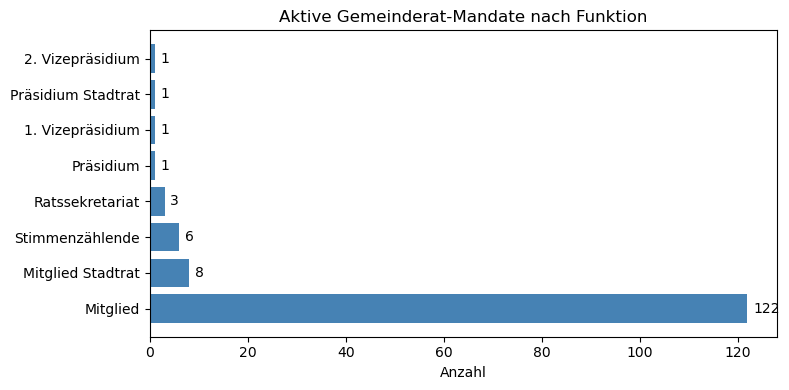


Aktive Ratsmitglieder (ohne Ersatz): 143


In [5]:
# Schritt 2: Funktion-Verteilung anzeigen
funktion_col = next((c for c in df_kontakte.columns if "Funktion" in c), None)

if funktion_col:
    print(f"Funktion-Spalte: {funktion_col}")
    print("\nVerteilung:")
    print(df_kontakte[funktion_col].value_counts().to_string())

    # Visualisierung
    funktion_counts = (
        df_kontakte[funktion_col]
        .value_counts()
        .reset_index()
        .rename(columns={funktion_col: "Funktion", "count": "Anzahl"})
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(funktion_counts["Funktion"], funktion_counts["Anzahl"], color="steelblue")
    ax.set_xlabel("Anzahl")
    ax.set_title("Aktive Gemeinderat-Mandate nach Funktion")
    ax.bar_label(ax.containers[0], padding=4)
    plt.tight_layout()
    plt.show()

    # Schritt 3: Nur ordentliche Sitze – Ersatzmitglieder ausschliessen
    df_kontakte_aktiv = df_kontakte[
        ~df_kontakte[funktion_col].str.contains("Ersatz", na=False)
    ].copy()
    print(f"\nAktive Ratsmitglieder (ohne Ersatz): {len(df_kontakte_aktiv)}")
    df_kontakte_aktiv.head(5)
else:
    print("Funktion-Spalte nicht gefunden. Verfügbare Spalten:", df_kontakte.columns.tolist())
    df_kontakte_aktiv = df_kontakte.copy()

In [6]:
# Spalten erkunden: welche persönlichen Felder liefert behoerdenmandat?
print(f"Spalten in df_kontakte_aktiv ({len(df_kontakte_aktiv.columns)} total):")
for c in sorted(df_kontakte_aktiv.columns):
    print(" ", c)

Spalten in df_kontakte_aktiv (26 total):
  Behordenmandat/AltsystemID
  Behordenmandat/Dauer/End
  Behordenmandat/Dauer/End@{http://www.w3.org/2001/XMLSchema-instance}nil
  Behordenmandat/Dauer/Start
  Behordenmandat/Dauer/Start@{http://www.w3.org/2001/XMLSchema-instance}nil
  Behordenmandat/Dauer/Text
  Behordenmandat/Funktion
  Behordenmandat/Gremium
  Behordenmandat/GremiumGuid
  Behordenmandat/Gremiumstyp
  Behordenmandat/KontaktGuid
  Behordenmandat/Name
  Behordenmandat/Partei
  Behordenmandat/ParteiGuid
  Behordenmandat/Sitz
  Behordenmandat/Sitz@{http://www.w3.org/2001/XMLSchema-instance}nil
  Behordenmandat/Titel
  Behordenmandat/Vorname
  Behordenmandat/Wahlkreis
  Behordenmandat/WahlkreisOrder@{http://www.w3.org/2001/XMLSchema-instance}nil
  Behordenmandat/Wohnkreis
  Behordenmandat@IDX
  Behordenmandat@OBJ_GUID
  Behordenmandat@SEQ
  _Guid
  _SEQ


In [7]:
# Relevante Felder automatisch aus behoerdenmandat-Spalten erkennen
def find_col(df, *keywords):
    """Gibt die erste Spalte zurück, die alle Schlüsselwörter enthält."""
    for c in df.columns:
        if all(kw.lower() in c.lower() for kw in keywords):
            return c
    return None

name_col      = find_col(df_kontakte_aktiv, "Name")
vorname_col   = find_col(df_kontakte_aktiv, "Vorname")
partei_col    = find_col(df_kontakte_aktiv, "Partei")
jahrgang_col  = find_col(df_kontakte_aktiv, "Jahrgang")
wahlkreis_col = find_col(df_kontakte_aktiv, "Wahlkreis")
wohnkreis_col = find_col(df_kontakte_aktiv, "Wohnkreis")
geschlecht_col = find_col(df_kontakte_aktiv, "Geschlecht")

print(f"Name:       {name_col}")
print(f"Vorname:    {vorname_col}")
print(f"Partei:     {partei_col}")
print(f"Jahrgang:   {jahrgang_col}")
print(f"Wahlkreis:  {wahlkreis_col}")
print(f"Wohnkreis:  {wohnkreis_col}")
print(f"Geschlecht: {geschlecht_col}")

basis_cols = [c for c in [name_col, vorname_col, partei_col, geschlecht_col,
                            jahrgang_col, wahlkreis_col, wohnkreis_col]
              if c is not None]

df_mitglieder = df_kontakte_aktiv[basis_cols].copy()
df_mitglieder.columns = [c.rsplit("/", 1)[-1] for c in basis_cols]
print(f"\nSpalten in df_mitglieder: {df_mitglieder.columns.tolist()}")
df_mitglieder.head(10)

Name:       Behordenmandat/Name
Vorname:    Behordenmandat/Vorname
Partei:     Behordenmandat/Partei
Jahrgang:   None
Wahlkreis:  Behordenmandat/Wahlkreis
Wohnkreis:  Behordenmandat/Wohnkreis
Geschlecht: None

Spalten in df_mitglieder: ['Name', 'Vorname', 'Partei', 'Wahlkreis', 'Wohnkreis']


,Name,Vorname,Partei,Wahlkreis,Wohnkreis
0,Avdili,Përparim,FDP.Die Liberalen,9,9
1,Blättler,Florian,Sozialdemokratische Partei,11,11
2,Bosshardt,Tamara,Sozialdemokratische Partei,11,11
3,Bourgeois,Yasmine,FDP.Die Liberalen,7 und 8,7
4,Braune,Stéphane,FDP.Die Liberalen,11,11
5,Bürgisser,Balz,Grüne Partei,7 und 8,7
6,Capaul,Flurin,FDP.Die Liberalen,3,3
7,Cassee,Tom,Sozialdemokratische Partei,3,2
8,Denoth,Marco,Sozialdemokratische Partei,6,4
9,Denoth,Marco,Sozialdemokratische Partei,6,4


### 4.2 Analyse: Sitzverteilung nach Partei


In [8]:
# Parteispalte im umbenannten DataFrame ermitteln
partei_kurz = partei_col.split("/")[-1] if partei_col else None

if partei_kurz and partei_kurz in df_mitglieder.columns:
    parteien = (
        df_mitglieder[partei_kurz]
        .value_counts()
        .reset_index()
        .rename(columns={partei_kurz: "Partei", "count": "Sitze"})
    )
    print(parteien.to_string(index=False))
else:
    print("Keine Parteispalte gefunden. Verfügbare Spalten:", df_mitglieder.columns.tolist())
    parteien = None


                    Partei  Sitze
Sozialdemokratische Partei     43
         FDP.Die Liberalen     26
              Grüne Partei     22
       Grünliberale Partei     18
Schweizerische Volkspartei     14
         Alternative Liste      8
                 Die Mitte      7
  Evangelische Volkspartei      4
                 Parteilos      1


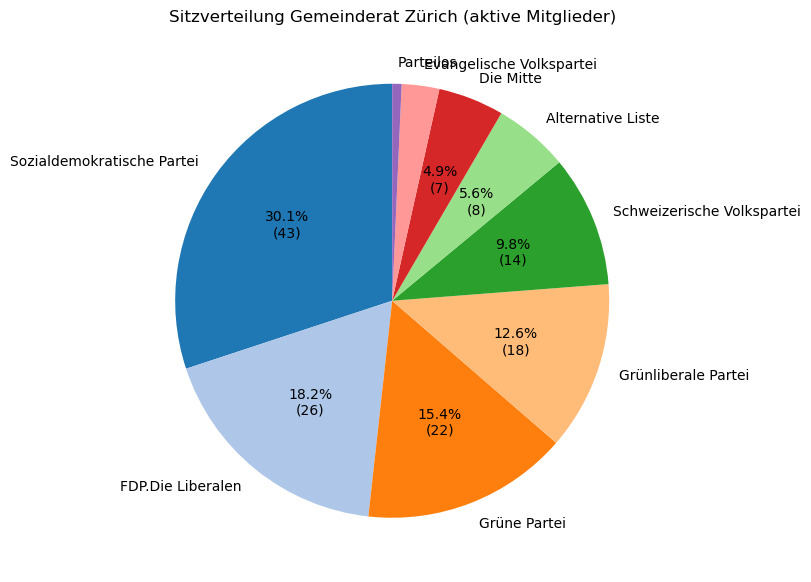

In [9]:
# Kreisdiagramm Parteienverteilung
if parteien is not None:
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = plt.cm.tab20.colors
    wedges, texts, autotexts = ax.pie(
        parteien["Sitze"],
        labels=parteien["Partei"],
        autopct=lambda p: f"{p:.1f}%\n({int(round(p * parteien['Sitze'].sum() / 100))})" if p > 3 else "",
        colors=colors,
        startangle=90,
    )
    ax.set_title("Sitzverteilung Gemeinderat Zürich (aktive Mitglieder)")
    plt.tight_layout()
    plt.show()
else:
    print("Keine Parteidaten für Grafik verfügbar.")


### 4.3 Einzelne Person suchen


In [10]:
# Kontakt nach Name und Vorname suchen
root_person = paris_search(
    "kontakt",
    'Name any "Müller" AND Vorname any "Peter"',
    max_rows=10
)
print(f"Treffer: {get_num_hits(root_person)}")

df_person = hits_to_dataframe(get_hits(root_person))
df_person.head()

Treffer: 0


""


### 4.4 Mitglieder einer Fraktion


In [11]:
# Alle SP-Ratsmitglieder
root_sp = paris_search("kontakt", 'Fraktion any "SP"', max_rows=100)
print(f"SP-Fraktion: {get_num_hits(root_sp)} Mitglieder")

df_sp = hits_to_dataframe(get_hits(root_sp))
name_cols = [c for c in df_sp.columns if "Name" in c or "Vorname" in c][:4]
df_sp[name_cols].head(10)

SP-Fraktion: 37 Mitglieder


,Kontakt/NameVorname,Kontakt/Name,Kontakt/Vorname,Kontakt/Bild@FileName
0,Muharemi Dafi,Muharemi,Dafi,Muharemi_Dafi
1,Merkler Ursina,Merkler,Ursina,Merkler_Ursina
2,Kägi Götz Maya,Kägi Götz,Maya,Kaegi_Goetz_Maya
3,Habegger Rahel,Habegger,Rahel,Habegger_Rahel
4,Bosshardt Tamara,Bosshardt,Tamara,Bosshardt_Tamara
5,Tscherrig Patrick,Tscherrig,Patrick,Tscherrig_Patrick
6,Mahrer Liv,Mahrer,Liv,Mahrer_Liv
7,de Weck Fanny,de Weck,Fanny,de_Weck_Fanny
8,Erdem Niyazi,Erdem,Niyazi,Erdem_Niyazi
9,Früh Anjushka,Früh,Anjushka,Frueh_Anjushka


### 4.5 Altersstruktur des Gemeinderats


In [12]:
if jahrgang_col and jahrgang_col in df_kontakte_aktiv.columns:
    jg_selected = [jahrgang_col]
    if partei_col and partei_col in df_kontakte_aktiv.columns:
        jg_selected.append(partei_col)
    if geschlecht_col and geschlecht_col in df_kontakte_aktiv.columns:
        jg_selected.append(geschlecht_col)

    df_mitglieder_jg = df_kontakte_aktiv[jg_selected].copy()
    df_mitglieder_jg[jahrgang_col] = pd.to_numeric(df_mitglieder_jg[jahrgang_col], errors="coerce")
    df_mitglieder_jg = df_mitglieder_jg.dropna(subset=[jahrgang_col])
    df_mitglieder_jg["Alter"] = date.today().year - df_mitglieder_jg[jahrgang_col]

    print(f"Durchschnittsalter: {df_mitglieder_jg['Alter'].mean():.1f} Jahre")
    print(f"Jüngstes Mitglied:  {int(df_mitglieder_jg['Alter'].min())} Jahre")
    print(f"Ältestes Mitglied:  {int(df_mitglieder_jg['Alter'].max())} Jahre")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(df_mitglieder_jg["Alter"], bins=15, color="steelblue", edgecolor="white")
    ax.axvline(df_mitglieder_jg["Alter"].mean(), color="coral", linewidth=2,
               label=f"Durchschnitt: {df_mitglieder_jg['Alter'].mean():.1f} J.")
    ax.set_xlabel("Alter")
    ax.set_ylabel("Anzahl Ratsmitglieder")
    ax.set_title("Altersverteilung im Gemeinderat Zürich")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Jahrgang-Spalte nicht verfügbar im behoerdenmandat-Index.")
    print("Tipp: Für Jahrgang kontakt-Index direkt abfragen oder behoerdenmandat mit kontakt verknüpfen.")

Jahrgang-Spalte nicht verfügbar im behoerdenmandat-Index.
Tipp: Für Jahrgang kontakt-Index direkt abfragen oder behoerdenmandat mit kontakt verknüpfen.


---
## 5. Ratsgeschäfte abfragen (Index: GESCHAEFT)

### 5.1 Einzelnes Geschäft nach GR-Nummer


In [13]:
# Ein spezifisches Geschäft nach GR-Nummer suchen
root = paris_search("geschaeft", 'GRNr any "2023/100"')

print(f"Treffer: {get_num_hits(root)}")
hits = get_hits(root)

# Rohe XML-Struktur eines Treffers anzeigen
if hits:
    print("\nXML-Struktur des ersten Treffers (Auszug):")
    print(ET.tostring(hits[0], encoding="unicode")[:2000])

Treffer: 1

XML-Struktur des ersten Treffers (Auszug):
<ns0:Hit xmlns:ns0="http://www.cmiag.ch/cdws/searchDetailResponse" xmlns:ns1="http://www.cmiag.ch/cdws/Geschaeft" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" Guid="8c9e088eec294f36a16f56807c6b7fa7" SEQ="5096198" Relevance="9.853896"><ns0:Snippet>&lt;EM&gt;2023/100  &lt;/EM&gt;</ns0:Snippet><ns1:Geschaeft OBJ_GUID="8c9e088eec294f36a16f56807c6b7fa7" SEQ="5096198" IDX="Geschaeft"><ns1:GRNr>2023/100</ns1:GRNr><ns1:GRNrSort>20230100</ns1:GRNrSort><ns1:Titel>Beeinträchtigung der Durchlüftung durch den Bau von Siedlungen, Berücksichtigung der Hitzeminderung bei grossen Bauvorhaben, rechtliche Grundlagen zur Prüfung der Durchlüftung, Beispiele für gelungene Bauprojekte und Projekte mit einem negativen Effekt sowie Schätzung der Kosten bei einer Beeinträchtigung der Durchlüftung</ns1:Titel><ns1:Geschaeftsart>Schriftliche Anfrage</ns1:Geschaeftsart><ns1:Geschaeftsstatus>Abgeschlossen</ns1:Geschaeftsstatus><ns1:Dringlich xsi:nil="fa

In [14]:
# Als DataFrame ausgeben
df_geschaeft = hits_to_dataframe(hits)
# Relevante Spalten anzeigen
cols = [c for c in df_geschaeft.columns if any(
    kw in c for kw in ["GRNr", "Titel", "Geschaeftsart", "PendentBei", "Beginn", "Dringlich"]
)]
df_geschaeft[cols].T

,0
Geschaeft/GRNr,2023/100
Geschaeft/GRNrSort,20230100
Geschaeft/Titel,"Beeinträchtigung der Durchlüftung durch den Bau von Siedlungen, Berücksichti..."
Geschaeft/Geschaeftsart,Schriftliche Anfrage
Geschaeft/Dringlich@{http://www.w3.org/2001/XMLSchema-instance}nil,false
Geschaeft/Dringlich,false
Geschaeft/Beginn/Start@{http://www.w3.org/2001/XMLSchema-instance}nil,false
Geschaeft/Beginn/Start,2023-03-01T00:00:00.000
Geschaeft/Beginn/End@{http://www.w3.org/2001/XMLSchema-instance}nil,false
Geschaeft/Beginn/End,2023-03-02T00:00:00.000


### 5.2 Alle Geschäfte eines Jahrgangs


In [15]:
# Alle Geschäfte im Jahr 2023 (Wildcard mit *)
root_2023 = paris_search("geschaeft", 'GRNr any "2023/*"', max_rows=1000)
num_hits = get_num_hits(root_2023)
print(f"Geschäfte 2023: {num_hits}")

df_2023 = hits_to_dataframe(get_hits(root_2023))
print(f"Spalten: {df_2023.columns.tolist()[:10]}...")
df_2023.head(3)

Geschäfte 2023: 597
Spalten: ['_Guid', '_SEQ', 'Geschaeft@OBJ_GUID', 'Geschaeft@SEQ', 'Geschaeft@IDX', 'Geschaeft/GRNr', 'Geschaeft/GRNrSort', 'Geschaeft/Titel', 'Geschaeft/Geschaeftsart', 'Geschaeft/Geschaeftsstatus']...


,_Guid,_SEQ,Geschaeft@OBJ_GUID,Geschaeft@SEQ,Geschaeft@IDX,Geschaeft/GRNr,Geschaeft/GRNrSort,Geschaeft/Titel,Geschaeft/Geschaeftsart,Geschaeft/Geschaeftsstatus,...,Geschaeft/MitbeteiligteDepartemente/Departement/Name,Geschaeft/Ablaufschritte/Aufgabe/Protokolleintrag,Geschaeft/Traktanden/Traktandum/Sitzung/Sitzung/Beginn,Geschaeft/Traktanden/Traktandum/Sitzung/Sitzung/Ende,Geschaeft/VerweisVon/Geschaeft@OBJ_GUID,Geschaeft/VerweisVon/Geschaeft/Titel,Geschaeft/VerweisVon/Geschaeft/GRNr,Geschaeft/AnzahlMitunterzeichnende,Geschaeft/WeitereVorberatendeKommissionen/Gremium@OBJ_GUID,Geschaeft/WeitereVorberatendeKommissionen/Gremium/Name
0,9536d77823f440c6b1aa72d17e5d8851,4725369,9536d77823f440c6b1aa72d17e5d8851,4725369,Geschaeft,2023/1,20230001,Tätigkeitsbericht 2022 der Geschäftsprüfungskommission (GPK),Bericht,Abgeschlossen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b265644390ac406183e853731da69a87,4725371,b265644390ac406183e853731da69a87,4725371,Geschaeft,2023/3,20230003,Postulat von Marion Schmid und Marcel Savarioud betreffend Auswertung der Ha...,Weisung,Abgeschlossen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,216c960f87a7430b831cc8fd497694f5,4725373,216c960f87a7430b831cc8fd497694f5,4725373,Geschaeft,2023/5,20230005,Individuelle Prämienverbilligung im Kanton Zürich,Erklärung,Abgeschlossen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Geschäftsarten analysieren
art_col = "Geschaeft/Geschaeftsart"
if art_col in df_2023.columns:
    df_arten = (
        df_2023[art_col]
        .value_counts()
        .reset_index()
        .rename(columns={art_col: "Geschäftsart", "count": "Anzahl"})
    )
    print(df_arten.to_string(index=False))
else:
    print("Verfügbare Spalten:", [c for c in df_2023.columns if "Geschaeft" in c][:15])

               Geschäftsart  Anzahl
                   Postulat     189
                    Weisung     144
       Schriftliche Anfrage     128
                  Erklärung      56
                     Motion      30
             Interpellation      18
               Ratsmitglied      15
                    Bericht       4
                       Wahl       4
                   Petition       2
           Einzelinitiative       2
            Beschlussantrag       1
      Rechtsmittelverfahren       1
         Behördeninitiative       1
Parlamentarische Initiative       1
         Globalbudgetantrag       1


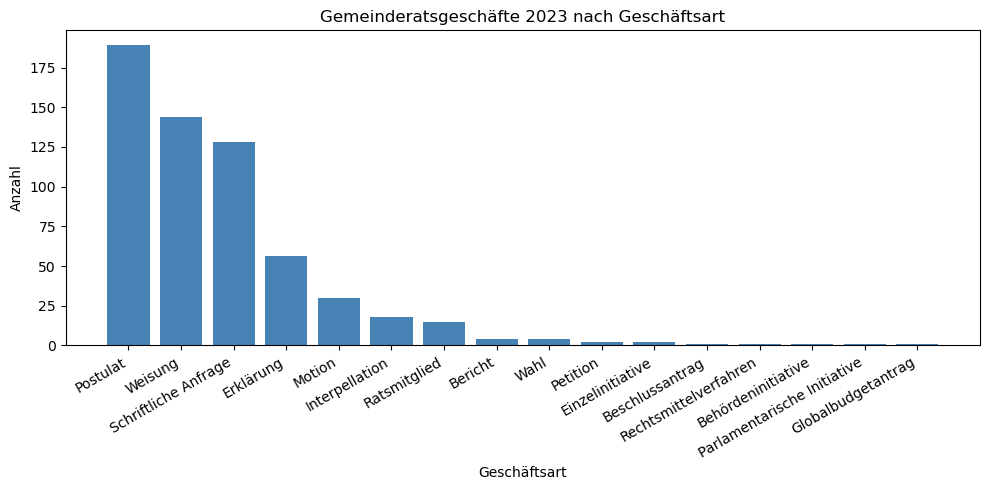

In [17]:
# Visualisierung: Geschäftsarten 2023
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_arten["Geschäftsart"], df_arten["Anzahl"], color="steelblue")
ax.set_xlabel("Geschäftsart")
ax.set_ylabel("Anzahl")
ax.set_title("Gemeinderatsgeschäfte 2023 nach Geschäftsart")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 5.3 Geschäfte nach Stichwort im Titel suchen


In [18]:
# Geschäfte zum Thema «Klimaschutz»
root_klima = paris_search("geschaeft", 'Titel any "Klimaschutz"', max_rows=50)
print(f"Treffer: {get_num_hits(root_klima)}")

df_klima = hits_to_dataframe(get_hits(root_klima))

# Relevante Spalten
cols = ["Geschaeft/GRNr", "Geschaeft/Titel", "Geschaeft/Geschaeftsart",
        "Geschaeft/PendentBei", "Geschaeft/Beginn"]
cols_available = [c for c in cols if c in df_klima.columns]
df_klima[cols_available].head(10)

Treffer: 6


,Geschaeft/GRNr,Geschaeft/Titel,Geschaeft/Geschaeftsart
0,2007/235,"Klimaschutz, Angebot an die Mitarbeitenden zur Reduktion von CO2-Emissionen",Motion
1,2020/543,Aktualisierung des regionalen Richtplans betreffend Klimaschutz und Netto-Nu...,Motion
2,2024/155,Urteil des Europäischen Gerichtshof für Menschenrechte (EGMR) zum Zusammenha...,Erklärung
3,2012/7,Förderung der Solarthermie und der Photovoltaik sowie Potential der Nutzung ...,Schriftliche Anfrage
4,2023/136,Motion von Simone Brander und Pascal Lamprecht betreffend Aktualisierung des...,Weisung
5,2020/509,Nutzung der CO2-Fo¨rdergelder der Stiftung Klimaschutz und CO2-Kompensation ...,Motion


### 5.4 Kombinierte CQL-Abfrage: Dringliche Motionen 2022–2024


In [19]:
# Dringliche Motionen in mehreren Jahren
query = (
    '(GRNr any "2022/*" OR GRNr any "2023/*" OR GRNr any "2024/*") '
    'AND Geschaeftsart any "Motion" '
    'AND Dringlich = true'
)

root_dringl = paris_search("geschaeft", query, max_rows=200)
print(f"Dringliche Motionen 2022-2024: {get_num_hits(root_dringl)}")

df_dringl = hits_to_dataframe(get_hits(root_dringl))
cols_available = [c for c in ["Geschaeft/GRNr", "Geschaeft/Titel", "Geschaeft/Beginn"] 
                  if c in df_dringl.columns]
df_dringl[cols_available]

Dringliche Motionen 2022-2024: 7


,Geschaeft/GRNr,Geschaeft/Titel
0,2024/549,Anstellung von betreuenden Angehörigen durch bestehende gemeinnützige Organi...
1,2023/596,Ausrichtung einer angemessenen Vergütung für künstlerische Arbeiten an die K...
2,2022/315,Investitions- und Betriebsbeitrag zur Sicherstellung und Förderung des Museu...
3,2023/562,Realisierung von gemeinnützigen Wohnungen und Gewerberäumen mit ausreichende...
4,2023/143,Sichere ebenerdige Querung an der Thurgauerstrasse im Bereich des Schulhauses
5,2023/318,Projektierungskredit für den Bau der Tramhaltestelle «Sihlquai» auf der Zoll...
6,2022/440,Verordnung für ein neues Vergütungsmodell für die Stromrücklieferung aus Pho...


### 5.5 Geschäfte nach Departement filtern


In [20]:
# Alle Geschäfte des Finanzdepartements im Jahr 2024
query = 'GRNr any "2024/*" AND Departement any "Finanzdepartement"'
root_fd = paris_search("geschaeft", query, max_rows=200)
print(f"Finanzdepartement 2024: {get_num_hits(root_fd)} Geschäfte")

df_fd = hits_to_dataframe(get_hits(root_fd))
cols_available = [c for c in ["Geschaeft/GRNr", "Geschaeft/Titel", "Geschaeft/Geschaeftsart"]
                  if c in df_fd.columns]
df_fd[cols_available].head(10)

Finanzdepartement 2024: 59 Geschäfte


,Geschaeft/GRNr,Geschaeft/Titel,Geschaeft/Geschaeftsart
0,2024/180,"Gegenvorschlag zur Volksinitiative «Bezahlbare Wohnungen für Zürich», Sicher...",Postulat
1,2024/207,"Finanzdepartement, Stiftung Einfach Wohnen, Kenntnisnahme Geschäftsbericht 2023",Weisung
2,2024/208,"Finanzdepartement, Stiftung Wohnungen für kinderreiche Familien, Kenntnisnah...",Weisung
3,2024/75,Zusammenführung der drei städtischen Wohnbaustiftungen sowie der Dienstabtei...,Postulat
4,2024/279,"Liegenschaft an der Krähbühlstrasse 58, Umnutzung als gemeinnützigen Wohnraum",Postulat
5,2024/292,"Finanzdepartement, Kongresshaus-Stiftung Zürich, Kenntnisnahme Geschäftsberi...",Weisung
6,2024/302,"Grundstücksteuereinnahmen bei städtischen Liegenschaftskäufen, Höhe der Steu...",Schriftliche Anfrage
7,2024/310,"Liegenschaften Stadt Zürich, Baurecht Aargauerstrasse 244, 250, 252 / Geeren...",Weisung
8,2024/45,"Grundstück Albishof, Ideen für die künftige Nutzung und Planungsfortschritt ...",Schriftliche Anfrage
9,2024/69,"Mögliche Verfehlungen bei städtischen Wohngenossenschaften, Auflistung der B...",Schriftliche Anfrage


### 5.6 Analyse: Geschäfte pro Jahr (mehrere Jahrgänge)


In [21]:
# Anzahl Geschäfte pro Jahr (2018 bis aktuelles Jahr)
aktuelles_jahr = date.today().year
jahre = range(2018, aktuelles_jahr + 1)
rows_jahre = []

for jahr in jahre:
    root = paris_search("geschaeft", f'GRNr any "{jahr}/*"', max_rows=1)
    rows_jahre.append({"Jahr": jahr, "Anzahl Geschäfte": get_num_hits(root)})

df_jahre = pd.DataFrame(rows_jahre)
df_jahre

,Jahr,Anzahl Geschäfte
0,2018,521
1,2019,562
2,2020,593
3,2021,517
4,2022,687
5,2023,597
6,2024,595
7,2025,625
8,2026,104


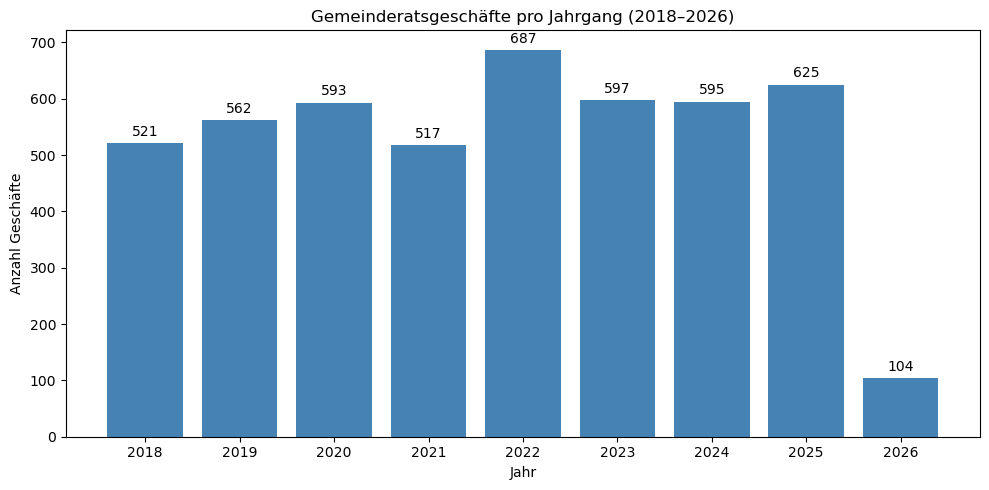

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_jahre["Jahr"].astype(str), df_jahre["Anzahl Geschäfte"], color="steelblue")
ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl Geschäfte")
ax.set_title(f"Gemeinderatsgeschäfte pro Jahrgang (2018–{aktuelles_jahr})")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

---
## 6. Ratssitzungen abfragen (Index: SITZUNG)

### 6.1 Sitzungen nach Datum

In [23]:
# Sitzungen im Jahr 2024 (Datumsbereich)
query_sitzungen = (
    'Sitzungsdatum_start >= "2024-01-01 00:00:00" '
    'AND Sitzungsdatum_start <= "2024-12-31 23:59:59" '
    'sortBy Sitzungsdatum_start/sort.ascending'
)

root_sitzungen = paris_search("sitzung", query_sitzungen, max_rows=100)
print(f"Sitzungen 2024: {get_num_hits(root_sitzungen)}")

df_sitzungen = hits_to_dataframe(get_hits(root_sitzungen))
df_sitzungen.head(3)

Sitzungen 2024: 46


,_Guid,_SEQ,Sitzung@OBJ_GUID,Sitzung@SEQ,Sitzung@IDX,Sitzung/Titel,Sitzung/Datum/Start@{http://www.w3.org/2001/XMLSchema-instance}nil,Sitzung/Datum/Start,Sitzung/Datum/End@{http://www.w3.org/2001/XMLSchema-instance}nil,Sitzung/Datum/End,...,Sitzung/Dokumente/Dokument/Kategorie,Sitzung/Sitzungsaufzeichnung/Dokument@OBJ_GUID,Sitzung/Sitzungsaufzeichnung/Dokument/Titel,Sitzung/Sitzungsaufzeichnung/Dokument/File@ID,Sitzung/Sitzungsaufzeichnung/Dokument/File@FileName,Sitzung/Sitzungsaufzeichnung/Dokument/File/Version@Nr,Sitzung/Sitzungsaufzeichnung/Dokument/File/Version/Rendition@Extension,Sitzung/Sitzungsaufzeichnung/Dokument/File/Version/Rendition@Ansicht,Sitzung/Sitzungsaufzeichnung/Dokument/Kategorie,Sitzung/Traktanden/Traktandum/Unterlagen/Unterlage/Dokumente/Dokument/Kategorie
0,85ba22b5a35244ffb10c9fdd68b8d098,5161291,85ba22b5a35244ffb10c9fdd68b8d098,5161291,Sitzung,81. Sitzung,false,2024-01-10T00:00:00.000,false,2024-01-11T00:00:00.000,...,"Tagliste, Varia, Audio-Sitzung, Protokoll, Protokoll",0ed4eca19fb640fa8ab0eb2d3f722fc7,Audio_Sitzung_ 20240110_81,0ed4eca19fb640fa8ab0eb2d3f722fc7-332,Audio_Sitzung_ 20240110_81,1,mp3,Original,Audio-Sitzung,NaN
1,9aea784db93443f199265c709bc7314f,4742575,9aea784db93443f199265c709bc7314f,4742575,Sitzung,82. Sitzung,false,2024-01-17T00:00:00.000,false,2024-01-18T00:00:00.000,...,"Tagliste, Audio-Sitzung, Protokoll, Protokoll",6e83be2da45b454b8c25d21197053c43,Audio_Sitzung_ 20240117_82,6e83be2da45b454b8c25d21197053c43-332,Audio_Sitzung_ 20240117_82,1,mp3,Original,Audio-Sitzung,NaN
2,560ac848f512484ba611642fcb35021b,4707558,560ac848f512484ba611642fcb35021b,4707558,Sitzung,83. Sitzung,false,2024-01-24T00:00:00.000,false,2024-01-25T00:00:00.000,...,"Tagliste, Audio-Sitzung, Protokoll, Protokoll",a72ff1a4c25e4bdfbfbef68752b6cc6d,Audio_Sitzung_ 20240124_83,a72ff1a4c25e4bdfbfbef68752b6cc6d-332,Audio_Sitzung_ 20240124_83,1,mp3,Original,Audio-Sitzung,NaN


In [24]:
# Relevante Sitzungsfelder extrahieren
sitzung_cols = [c for c in df_sitzungen.columns
                if any(kw in c for kw in ["Titel", "Datum", "Nummer"])
                and c.count("/") <= 2]
print("Sitzungs-Spalten:", sitzung_cols)

if sitzung_cols:
    df_sitzungen[sitzung_cols].head(10)

Sitzungs-Spalten: ['Sitzung/Titel', 'Sitzung/Datum/Start', 'Sitzung/Datum/End', 'Sitzung/Datum/Text']


### 6.2 Kommende Sitzungen

In [25]:
heute = date.today().strftime("%Y-%m-%d 00:00:00")

root_naechste = paris_search(
    "sitzung",
    f'Sitzungsdatum_start > "{heute}" sortBy Sitzungsdatum_start/sort.ascending',
    max_rows=10
)
print(f"Nächste Sitzungen ab heute: {get_num_hits(root_naechste)}")

df_naechste = hits_to_dataframe(get_hits(root_naechste))
sitzung_cols = [c for c in df_naechste.columns if c.count("/") <= 2]
df_naechste[sitzung_cols[:8]].head()

Nächste Sitzungen ab heute: 6


,_Guid,_SEQ,Sitzung@OBJ_GUID,Sitzung@SEQ,Sitzung@IDX,Sitzung/Titel,Sitzung/Datum/Start,Sitzung/Datum/End
0,0da9e36462004349b944aee5c271cb7f,5402332,0da9e36462004349b944aee5c271cb7f,5402332,Sitzung,181. Sitzung,2026-03-11T00:00:00.000,2026-03-12T00:00:00.000
1,9a702524adb140bcab989635d2f9b065,5401972,9a702524adb140bcab989635d2f9b065,5401972,Sitzung,182. Sitzung,2026-03-18T00:00:00.000,2026-03-19T00:00:00.000
2,4f6bcdb9a39e4ea594d226857085cb84,5401516,4f6bcdb9a39e4ea594d226857085cb84,5401516,Sitzung,183. Sitzung,2026-03-25T00:00:00.000,2026-03-26T00:00:00.000
3,78e15cb7a50042d48f2384156737e4e9,5401666,78e15cb7a50042d48f2384156737e4e9,5401666,Sitzung,184. Sitzung,2026-04-01T00:00:00.000,2026-04-02T00:00:00.000
4,016009fe4f764f97a6dd021757ed5a83,5384732,016009fe4f764f97a6dd021757ed5a83,5384732,Sitzung,185. Sitzung,2026-04-08T00:00:00.000,2026-04-09T00:00:00.000


---
## 7. Behördenmandate abfragen (Index: BEHOERDENMANDAT)

Über Behördenmandate kann ermittelt werden, wer aktuell oder in einer Zeitspanne ein Mandat in einem bestimmten Gremium innehat.

In [26]:
# Alle Behördenmandate im Gemeinderat laden
# Hinweis: Das Feld 'Dauer' existiert nicht im Index; alle Mandate werden geladen
# und können anschliessend Python-seitig nach offenem Ende gefiltert werden.
query_mandate = 'Gremium any "Gemeinderat"'

root_mandate = paris_search("behoerdenmandat", query_mandate, max_rows=200)
print(f"Mandate Gemeinderat: {get_num_hits(root_mandate)}")

df_mandate = hits_to_dataframe(get_hits(root_mandate))
df_mandate.head(3)


Mandate Gemeinderat: 823


,_Guid,_SEQ,Behordenmandat@OBJ_GUID,Behordenmandat@SEQ,Behordenmandat@IDX,Behordenmandat/Name,Behordenmandat/Vorname,Behordenmandat/KontaktGuid,Behordenmandat/AltsystemID,Behordenmandat/Dauer/Start@{http://www.w3.org/2001/XMLSchema-instance}nil,...,Behordenmandat/Gremiumstyp,Behordenmandat/Partei,Behordenmandat/ParteiGuid,Behordenmandat/Wahlkreis,Behordenmandat/WahlkreisOrder@{http://www.w3.org/2001/XMLSchema-instance}nil,Behordenmandat/Wohnkreis,Behordenmandat/Funktion,Behordenmandat/Sitz@{http://www.w3.org/2001/XMLSchema-instance}nil,Behordenmandat/Sitz,Behordenmandat/Titel
0,3c36ba11e98243569aaa49c7edd34b88,5033975,3c36ba11e98243569aaa49c7edd34b88,5033975,Behoerdenmandat,Angst,Walter,f3d3f6d5fda44de5b7247e8721eed7b4,EE8204F4-9290-49CA-99AE-D18A22A0A513,false,...,Gemeinderat,Alternative Liste,13dbe4a033864ef79dcd8f5869a01498,3,true,3,Mitglied,true,NaN,NaN
1,308e91fe98734b35bc528c8ed6784a9a,5033977,308e91fe98734b35bc528c8ed6784a9a,5033977,Behoerdenmandat,Avdili,Përparim,b879282b6a0f443d8d7da03f3bd8e7e0,40F5621F-CD63-4650-8F59-0C19F83FDB1F,false,...,Gemeinderat,FDP.Die Liberalen,7c21c5370bf0443ca7dab443656267f2,9,true,9,Mitglied,false,79,NaN
2,5bcb54e6b7414ccdab7c2dad33821d90,5033982,5bcb54e6b7414ccdab7c2dad33821d90,5033982,Behoerdenmandat,Blättler,Florian,6af35f85c14a48ce89f69a834cd4f627,78B66FF6-B873-4A13-AA6B-AFC966D332FF,false,...,Gemeinderat,Sozialdemokratische Partei,acaf62cfb36e44c4896ffac617848318,11,true,11,Mitglied,false,141,Dr.


In [27]:
# Funktion (Präsidium, Mitglied, etc.) analysieren
funktion_col = next((c for c in df_mandate.columns if "Funktion" in c), None)
if funktion_col:
    print(df_mandate[funktion_col].value_counts().to_string())
else:
    print("Verfügbare Spalten:", [c for c in df_mandate.columns if c.count("/") <= 2][:10])

Behordenmandat/Funktion
Mitglied             176
Mitglied Stadtrat      7
Ratssekretariat        6
Stimmenzählende        4
1. Vizepräsidium       3
Präsidium              3
2. Vizepräsidium       1


---
## 8. Dokumente abfragen & herunterladen

Dokumente (PDFs) können über die API in zwei Schritten abgerufen werden:
1. Metadaten per `dokument/searchdetails`
2. Binärdatei per `https://www.gemeinderat-zuerich.ch/dokumente/{file-id}`

In [28]:
# Zuerst: Dokument-GUID aus einem Geschäft holen
root_gs = paris_search("geschaeft", 'GRNr any "2023/100"', max_rows=1)
hits_gs = get_hits(root_gs)

if hits_gs:
    xml_str = ET.tostring(hits_gs[0], encoding="unicode")
    # Dokument-GUIDs im XML suchen
    import re
    guids = re.findall(r'OBJ_GUID="([a-f0-9]{32})"', xml_str)
    file_ids = re.findall(r'ID="([a-f0-9]{32}-\d+)"', xml_str)
    print(f"Gefundene OBJ_GUIDs: {guids}")
    print(f"Gefundene File-IDs:  {file_ids}")

Gefundene OBJ_GUIDs: ['8c9e088eec294f36a16f56807c6b7fa7', '6a11bc73f3064b5e82ed5378594452ee', '2735982a7cf44f94847d0d97e31d2d87', '91be9420934d408ebf937aeb04331c5d', 'c990b795858d4f038d8473f4a8d8f2c7', '7ae904ac7c0b42e7bb913d3ea0556207', 'd20fc0fc74ca4184b6eeb90d57dc04e4', 'e1c664d4b1884326ab292891e7618cf8', '02e4a3b4ed5c4f0492c075e7713892bf', '98406de291bb4ae38fcaac14c76c2e8d', '61fde64631a24a59b6b244941aa7d02d', '27f3d9de01a440a1a31ab666e9e9c07c']
Gefundene File-IDs:  ['91be9420934d408ebf937aeb04331c5d-332', 'c990b795858d4f038d8473f4a8d8f2c7-332', 'd20fc0fc74ca4184b6eeb90d57dc04e4-332', '02e4a3b4ed5c4f0492c075e7713892bf-332']


In [29]:
def get_document_metadata(doc_guid: str) -> pd.DataFrame:
    """Ruft Metadaten eines Dokuments anhand der OBJ_GUID ab."""
    root = paris_search("dokument", f'ID adj "{doc_guid}"')
    return hits_to_dataframe(get_hits(root))


def get_document_url(file_id: str) -> str:
    """Gibt die Download-URL für ein Dokument zurück (ohne /api/ Pfadbestandteil)."""
    return f"https://www.gemeinderat-zuerich.ch/dokumente/{file_id}"


# Beispiel: Metadaten eines bekannten Dokuments
# (GUID aus dem Geschäft oben, falls vorhanden)
if guids:
    df_doc_meta = get_document_metadata(guids[0])
    print("Dokument-Metadaten:")
    df_doc_meta.T
else:
    print("Keine Dokument-GUIDs gefunden.")

# Beispiel-Download-URL
if file_ids:
    download_url = get_document_url(file_ids[0])
    print(f"\nDownload-URL: {download_url}")

Dokument-Metadaten:

Download-URL: https://www.gemeinderat-zuerich.ch/dokumente/91be9420934d408ebf937aeb04331c5d-332


---
## 9. Gremien abfragen (Index: GREMIUMSUEBERSICHT)

Alle Kommissionen, Fraktionen und anderen Gremien des Gemeinderats.

In [30]:
# Alle Sachkommissionen
root_sk = paris_search(
    "gremiumsuebersicht",
    'Gremiumstyp any "Sachkommission"',
    max_rows=100
)
print(f"Sachkommissionen: {get_num_hits(root_sk)}")

df_sk = hits_to_dataframe(get_hits(root_sk))
name_cols = [c for c in df_sk.columns if "Name" in c or "Kurzname" in c][:4]
df_sk[name_cols].head(10)

Sachkommissionen: 0


""


In [31]:
# Alle Gremiumstypen
root_typen = paris_search("gremiumstyp", "seq>0", max_rows=50)
df_typen = hits_to_dataframe(get_hits(root_typen))
name_cols = [c for c in df_typen.columns if "Name" in c]
if name_cols:
    print(df_typen[name_cols[0]].tolist())
else:
    df_typen.head()

['Fraktion', 'Parlamentarische Gruppe', 'Kommission', 'Gemeinderat', 'Geschäftsleitung', 'Ratsexterne Kommission/Stiftung']


---
## 10. Paginierung: Grosse Datenmenge laden

Die API liefert maximal **1000 Treffer pro Anfrage**. Für grössere Datenmengen wird Paginierung benötigt.
Die Hilfsfunktion `load_all_pages()` (aus Kapitel 1) erledigt das automatisch.

In [32]:
# Alle Geschäfte seit 2020 bis aktuelles Jahr laden (paginiert)
aktuelles_jahr = date.today().year
startjahr = 2020
jahres_query = " OR ".join(f'GRNr any "{j}/*"' for j in range(startjahr, aktuelles_jahr + 1))

df_alle = load_all_pages(
    index="geschaeft",
    query=jahres_query,
    page_size=500,
    max_total=3000,
)
print(f"\nGeladene Datensätze: {len(df_alle):,}")
df_alle.head(3)

Gesamt: 3,718 Treffer, lade 3,000
  Geladen: 3,000 / 3,000

Geladene Datensätze: 3,000


,_Guid,_SEQ,Geschaeft@OBJ_GUID,Geschaeft@SEQ,Geschaeft@IDX,Geschaeft/GRNr,Geschaeft/GRNrSort,Geschaeft/Titel,Geschaeft/Geschaeftsart,Geschaeft/Geschaeftsstatus,...,Geschaeft/VorberatendeKommission/Gremium/Name,Geschaeft/Ablaufschritte/Aufgabe/Protokolleintrag,Geschaeft/VerweisVon/Geschaeft@OBJ_GUID,Geschaeft/VerweisVon/Geschaeft/Titel,Geschaeft/VerweisVon/Geschaeft/GRNr,Geschaeft/MitbeteiligteDepartemente/Departement@OBJ_GUID,Geschaeft/MitbeteiligteDepartemente/Departement/Name,Geschaeft/WeitereVorberatendeKommissionen/Gremium@OBJ_GUID,Geschaeft/WeitereVorberatendeKommissionen/Gremium/Name,Geschaeft/Ablaufschritte/Aufgabe/ProtokolleintragHTML
0,6d2595b1236c4cf8852c5447c22548e9,5309550,6d2595b1236c4cf8852c5447c22548e9,5309550,Geschaeft,2026/10,20260010,Beurteilungskriterien für den Projektwettbewerb «Betreuungsgebäude Auhofstra...,Schriftliche Anfrage,InBearbeitung,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,efeef063d0ab4f95ad9f05a535456ac1,5309559,efeef063d0ab4f95ad9f05a535456ac1,5309559,Geschaeft,2026/14,20260014,"Unterstützung des Moods, Entwicklung der Besuchendenzahlen und Einschätzung ...",Schriftliche Anfrage,InBearbeitung,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0e6ea5747f484f9bb2c7abc3ae8f904e,5311265,0e6ea5747f484f9bb2c7abc3ae8f904e,5311265,Geschaeft,2026/1,20260001,Tätigkeitsbericht 2025 der Geschäftsprüfungskommission (GPK),Bericht,InBearbeitung,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


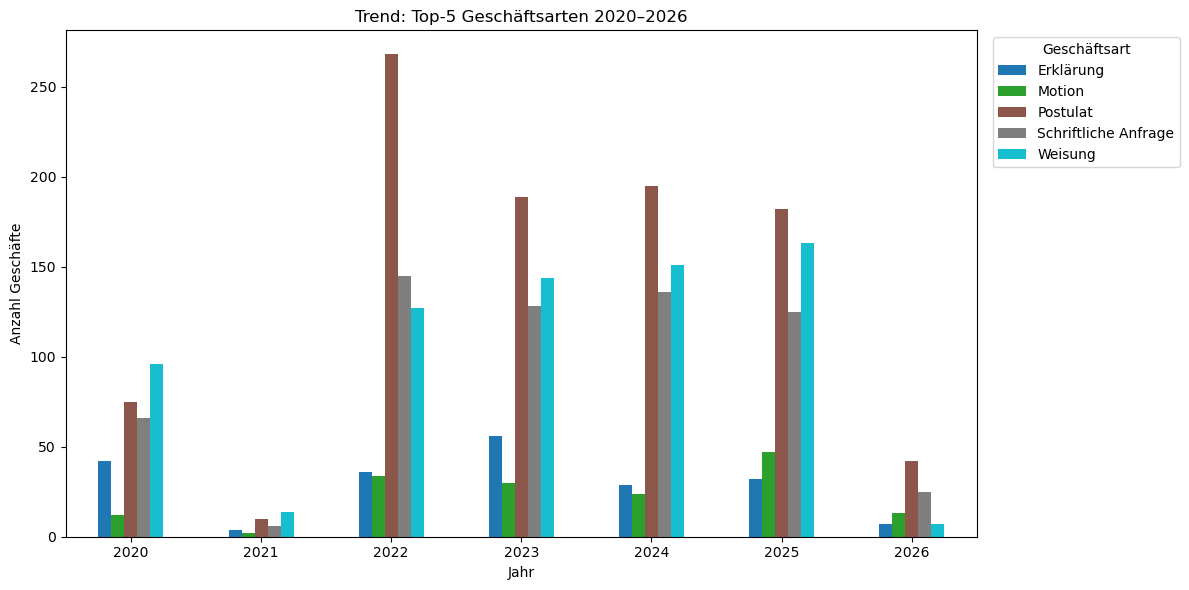

In [33]:
# Geschäftsart-Trend über Jahre
art_col  = "Geschaeft/Geschaeftsart"
grnr_col = "Geschaeft/GRNr"

if art_col in df_alle.columns and grnr_col in df_alle.columns:
    df_alle["Jahr"] = df_alle[grnr_col].str.extract(r"(\d{4})")[0]
    df_alle = df_alle.dropna(subset=["Jahr"])
    df_alle["Jahr"] = df_alle["Jahr"].astype(int)

    # Top-5 Geschäftsarten
    top5_arten = df_alle[art_col].value_counts().head(5).index.tolist()

    df_trend = (
        df_alle[df_alle[art_col].isin(top5_arten)]
        .groupby(["Jahr", art_col])
        .size()
        .unstack(art_col, fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    df_trend.plot(kind="bar", ax=ax, colormap="tab10")
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Anzahl Geschäfte")
    ax.set_title(f"Trend: Top-5 Geschäftsarten {startjahr}–{aktuelles_jahr}")
    ax.legend(title="Geschäftsart", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Benötigte Spalten nicht gefunden. Verfügbar:",
          [c for c in df_alle.columns if c.count("/") <= 1][:10])


---
## 11. Praxisbeispiel: Wer hat wie viele Vorstösse eingereicht?

Kombination mehrerer Abfragen: Erstunterzeichnende pro Person auswerten.

In [34]:
# Vorstösse 2022–2026 laden
vorst_jahre = range(2022, 2027)
query_vorstoesse = (
    "(" + " OR ".join(f'GRNr any "{y}/*"' for y in vorst_jahre) + ") "
    'AND (Geschaeftsart any "Motion" OR Geschaeftsart any "Postulat" '
    'OR Geschaeftsart any "Interpellation" OR Geschaeftsart any "Schriftliche Anfrage")'
)

root_vs = paris_search("geschaeft", query_vorstoesse, max_rows=1000)
print(f"Vorstösse 2022–2026: {get_num_hits(root_vs)}")

df_vs = hits_to_dataframe(get_hits(root_vs))

# Jahr aus GR-Nummer extrahieren
grnr_col = "Geschaeft/GRNr"
if grnr_col in df_vs.columns:
    df_vs["Jahr"] = df_vs[grnr_col].str.extract(r"(\d{4})")[0].astype(int)

# Erstunterzeichner-Spalte suchen
eu_cols = [c for c in df_vs.columns if "Erstunterzeichner" in c and "Name" in c]
print("Erstunterzeichner-Spalten:", eu_cols)


Vorstösse 2022–2026: 1652
Erstunterzeichner-Spalten: ['Geschaeft/Erstunterzeichner/KontaktGremium/Name']


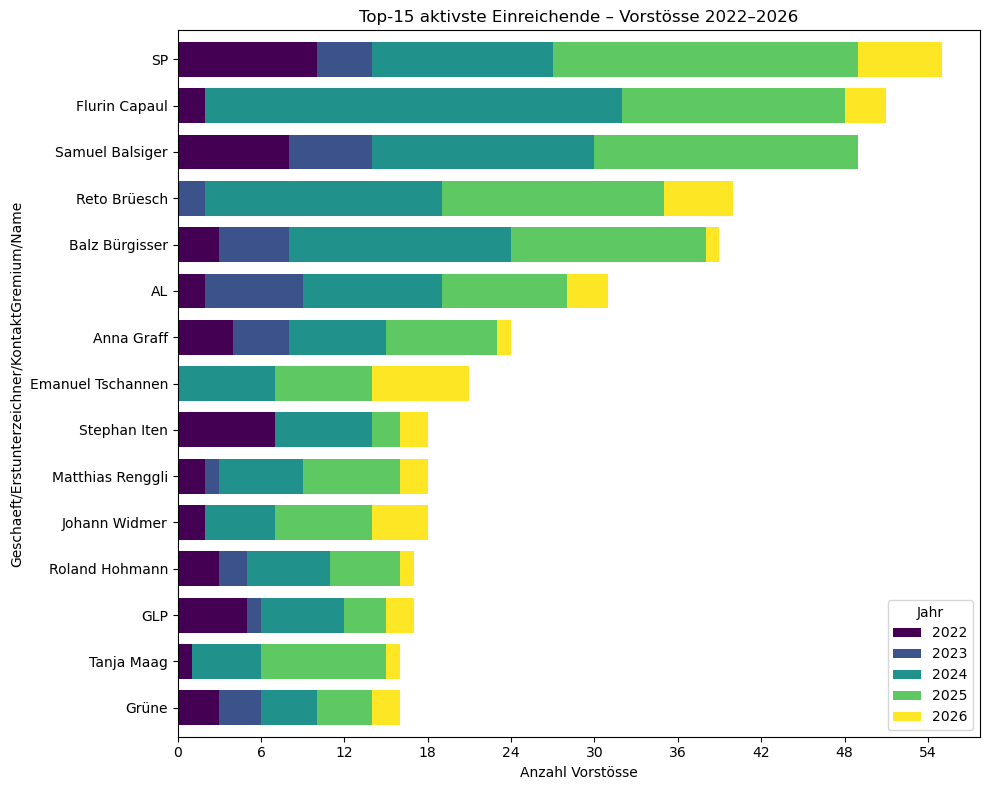

In [35]:
if eu_cols and "Jahr" in df_vs.columns:
    eu_col = eu_cols[0]

    # Top-15 Einreichende insgesamt (2022-2026)
    top_personen = df_vs[eu_col].value_counts().head(15).index

    # Pivot: Person (Zeilen) x Jahr (Spalten)
    df_pivot = (
        df_vs[df_vs[eu_col].isin(top_personen)]
        .groupby([eu_col, "Jahr"])
        .size()
        .unstack("Jahr", fill_value=0)
    )

    # Sicherstellen, dass alle Jahre 2022-2026 vorhanden
    for j in vorst_jahre:
        if j not in df_pivot.columns:
            df_pivot[j] = 0
    df_pivot = df_pivot[sorted(df_pivot.columns)]

    # Sortierung nach Gesamtzahl (aufsteigend für horizontale Balken)
    df_pivot = df_pivot.loc[df_pivot.sum(axis=1).sort_values(ascending=True).index]

    fig, ax = plt.subplots(figsize=(10, 8))
    df_pivot.plot(kind="barh", stacked=True, ax=ax,
                  colormap="viridis", width=0.75)
    ax.set_xlabel("Anzahl Vorstösse")
    ax.set_title("Top-15 aktivste Einreichende – Vorstösse 2022–2026")
    ax.legend(title="Jahr", loc="lower right")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()
elif eu_cols:
    print("Jahr-Spalte fehlt.")
else:
    print("Erstunterzeichner-Spalte nicht gefunden.")


---
## 12. Zusammenfassung

### Wichtigste Konzepte

| Konzept | Details |
|---|---|
| **Basis-URL** | `https://www.gemeinderat-zuerich.ch/api/{index}/{funktion}` |
| **Datenformat** | XML (Namespace: `http://www.cmiag.ch/cdws/...`) |
| **Sprache** | Immer `l=de-CH` angeben |
| **Alle Objekte** | `q=seq>0` |
| **Paginierung** | `s` (Start) + `m` (Max, max. 1000) |
| **Dokument-Download** | `https://www.gemeinderat-zuerich.ch/dokumente/{file-id}` |

### CQL-Kurzreferenz

```cql
# Text-Suche
Titel any "Klimaschutz"                  # mind. ein Wort
Titel all "Klimaschutz Massnahmen"        # alle Wörter
Titel adj "Klimaschutz Massnahmen"        # exakte Phrase

# Datum
Sitzungsdatum_start >= "2024-01-01 00:00:00"
Dauer_end > "9999-12-31 00:00:00"         # offene Mandate

# Boolean
Dringlich = true
AktivesRatsmitglied = false

# Kombiniert
GRNr any "2023/*" AND Geschaeftsart any "Motion"

# Sortierung
seq>0 sortBy Name/sort.ascending
```

### Nützliche Links

- **Portal**: https://www.gemeinderat-zuerich.ch
- **API Basis-URL**: https://www.gemeinderat-zuerich.ch/api/
- **Schema-Beispiel**: https://www.gemeinderat-zuerich.ch/api/geschaeft/schema
- **OGD Datensatz**: https://data.stadt-zuerich.ch/dataset/parlamentsdienste_paris_api
- **CQL Spezifikation**: http://www.loc.gov/standards/sru/specs/cql.html